# 02. Audio Feature Extraction

This notebook converts each selected ESC-50 recording into numerical features for machine learning.

Features extracted:

- 13 MFCC mean values
- 13 MFCC standard deviation values
- Zero-crossing rate
- Spectral centroid
- Spectral bandwidth
- Spectral roll-off
- RMS energy

The final table will be saved as:

`data/processed/audio_features.csv`


In [11]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. Locate the project and dataset


In [12]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "ESC-50"
METADATA_PATH = DATASET_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = DATASET_ROOT / "audio"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_PATH = OUTPUT_DIR / "audio_features_all_50.csv"

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        "ESC-50 metadata was not found at:\n"
        f"{METADATA_PATH}"
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Audio folder: {AUDIO_DIR}")
print(f"Output file: {OUTPUT_PATH}")


Project root: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier
Audio folder: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\data\raw\ESC-50\audio
Output file: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\data\processed\audio_features_all_50.csv


## 2. Load metadata and select five classes


In [13]:
metadata = pd.read_csv(METADATA_PATH)

selected_data = metadata.copy()

selected_data = selected_data.sort_values(
    ["category", "fold", "filename"]
).reset_index(drop=True)

print(f"Selected recordings: {len(selected_data)}")
print(f"Number of classes: {selected_data['category'].nunique()}")


Selected recordings: 2000
Number of classes: 50


## 3. Define the feature extraction function

Each audio recording is converted into one row of numbers.


In [14]:
def extract_audio_features(
    file_path: Path,
    target_sample_rate: int = 22050,
    number_of_mfccs: int = 13,
) -> dict:
    """Extract numerical features from one audio recording."""

    signal, sample_rate = librosa.load(
        file_path,
        sr=target_sample_rate,
        mono=True,
    )

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=number_of_mfccs,
    )

    zero_crossing_rate = librosa.feature.zero_crossing_rate(signal)
    spectral_centroid = librosa.feature.spectral_centroid(
        y=signal,
        sr=sample_rate,
    )
    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=signal,
        sr=sample_rate,
    )
    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=signal,
        sr=sample_rate,
        roll_percent=0.85,
    )
    rms_energy = librosa.feature.rms(y=signal)

    features = {}

    for index in range(number_of_mfccs):
        features[f"mfcc_{index + 1}_mean"] = float(np.mean(mfcc[index]))
        features[f"mfcc_{index + 1}_std"] = float(np.std(mfcc[index]))

    features["zero_crossing_rate_mean"] = float(np.mean(zero_crossing_rate))
    features["spectral_centroid_mean"] = float(np.mean(spectral_centroid))
    features["spectral_bandwidth_mean"] = float(np.mean(spectral_bandwidth))
    features["spectral_rolloff_mean"] = float(np.mean(spectral_rolloff))
    features["rms_energy_mean"] = float(np.mean(rms_energy))

    return features


## 4. Test the function on one recording


In [15]:
test_row = selected_data.iloc[0]
test_file_path = AUDIO_DIR / test_row["filename"]

test_features = extract_audio_features(test_file_path)

print(f"File: {test_row['filename']}")
print(f"Class: {test_row['category']}")
print(f"Number of extracted features: {len(test_features)}")

pd.Series(test_features).head(10)


File: 1-11687-A-47.wav
Class: airplane
Number of extracted features: 31


mfcc_1_mean    -68.407730
mfcc_1_std     117.749306
mfcc_2_mean     78.223381
mfcc_2_std      34.157211
mfcc_3_mean      4.756897
mfcc_3_std      11.442808
mfcc_4_mean     44.302052
mfcc_4_std      18.604342
mfcc_5_mean     14.698249
mfcc_5_std       7.435868
dtype: float64

The function should extract 31 features:

- 26 MFCC values
- 5 additional spectral and energy features


## 5. Extract features from all recordings

This can take one or two minutes.


In [16]:
feature_rows = []
total_files = len(selected_data)

for position, row in selected_data.iterrows():
    audio_path = AUDIO_DIR / row["filename"]

    try:
        features = extract_audio_features(audio_path)
        features["filename"] = row["filename"]
        features["fold"] = int(row["fold"])
        features["target"] = int(row["target"])
        features["category"] = row["category"]
        feature_rows.append(features)

    except Exception as error:
        print(f"Could not process {row['filename']}: {error}")

    completed = position + 1

    if completed % 20 == 0 or completed == total_files:
        print(f"Processed {completed}/{total_files} recordings")

features_df = pd.DataFrame(feature_rows)

print()
print(f"Completed rows: {len(features_df)}")
print(f"Total columns: {len(features_df.columns)}")


Processed 20/2000 recordings
Processed 40/2000 recordings
Processed 60/2000 recordings
Processed 80/2000 recordings
Processed 100/2000 recordings
Processed 120/2000 recordings
Processed 140/2000 recordings
Processed 160/2000 recordings
Processed 180/2000 recordings
Processed 200/2000 recordings
Processed 220/2000 recordings
Processed 240/2000 recordings
Processed 260/2000 recordings
Processed 280/2000 recordings
Processed 300/2000 recordings
Processed 320/2000 recordings
Processed 340/2000 recordings
Processed 360/2000 recordings
Processed 380/2000 recordings
Processed 400/2000 recordings
Processed 420/2000 recordings
Processed 440/2000 recordings
Processed 460/2000 recordings
Processed 480/2000 recordings
Processed 500/2000 recordings
Processed 520/2000 recordings
Processed 540/2000 recordings
Processed 560/2000 recordings
Processed 580/2000 recordings
Processed 600/2000 recordings
Processed 620/2000 recordings
Processed 640/2000 recordings
Processed 660/2000 recordings
Processed 680/

In [21]:
metadata_columns = [
    "filename",
    "fold",
    "target",
    "category",
]

feature_columns = [
    column
    for column in features_df.columns
    if column not in metadata_columns
]

features_df = features_df[
    metadata_columns + feature_columns
]

OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "audio_features_all_50.csv"
)

features_df.to_csv(OUTPUT_PATH, index=False)

print("Saved to:", OUTPUT_PATH)
print("Shape:", features_df.shape)
print("Number of classes:", features_df["category"].nunique())

Saved to: C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\data\processed\audio_features_all_50.csv
Shape: (2000, 35)
Number of classes: 50


## 6. Inspect the feature table


In [22]:
features_df.head()


,filename,fold,target,category,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,...,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,zero_crossing_rate_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,rms_energy_mean
0,1-11687-A-47.wav,1,47,airplane,-68.407730,117.749306,78.223381,34.157211,4.756897,11.442808,...,6.216324,10.396147,6.988348,-1.341286,5.133182,0.137854,2674.141151,2627.421648,5795.322673,0.183195
1,1-24796-A-47.wav,1,47,airplane,34.127151,72.993164,65.127335,22.012934,-12.650159,12.633339,...,4.449233,6.808112,5.648208,-0.187221,4.383595,0.218474,3223.180663,2617.969055,6310.125732,0.240778
2,1-36929-A-47.wav,1,47,airplane,-129.324219,14.076441,189.748535,9.874305,-44.204517,7.323853,...,4.013986,-4.395473,4.460861,-4.997627,4.397005,0.049714,1092.937486,1291.591579,2787.901815,0.272882
3,1-43807-A-47.wav,1,47,airplane,-166.561600,33.534286,216.454849,19.463509,-29.961597,10.657622,...,5.545503,-11.170605,7.190721,-5.914539,4.404808,0.027344,751.389041,1034.102682,1423.334757,0.183570
4,1-43807-B-47.wav,1,47,airplane,-327.550720,17.159882,241.709198,12.252018,13.818749,11.284963,...,5.151096,4.208405,4.476974,2.099718,4.411973,0.019050,428.805582,746.835156,726.346842,0.074196


In [18]:
print("Total missing values:")
print(features_df.isna().sum().sum())

print()
print("Class distribution:")
print(features_df["category"].value_counts().sort_index())


Total missing values:
0

Class distribution:
category
airplane            40
breathing           40
brushing_teeth      40
can_opening         40
car_horn            40
cat                 40
chainsaw            40
chirping_birds      40
church_bells        40
clapping            40
clock_alarm         40
clock_tick          40
coughing            40
cow                 40
crackling_fire      40
crickets            40
crow                40
crying_baby         40
dog                 40
door_wood_creaks    40
door_wood_knock     40
drinking_sipping    40
engine              40
fireworks           40
footsteps           40
frog                40
glass_breaking      40
hand_saw            40
helicopter          40
hen                 40
insects             40
keyboard_typing     40
laughing            40
mouse_click         40
pig                 40
pouring_water       40
rain                40
rooster             40
sea_waves           40
sheep               40
siren               40
sne

## 7. Arrange the columns and save the CSV file


In [23]:
metadata_columns = [
    "filename",
    "fold",
    "target",
    "category",
]

feature_columns = [
    column
    for column in features_df.columns
    if column not in metadata_columns
]

features_df = features_df[
    metadata_columns + feature_columns
]

features_df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved feature file to:\n{OUTPUT_PATH}")
print(f"Saved shape: {features_df.shape}")


Saved feature file to:
C:\Users\BASIL THOMAS\Desktop\audio-ml-classifier\data\processed\audio_features_all_50.csv
Saved shape: (2000, 35)


The expected shape is:

`(200, 35)`

This consists of 4 metadata columns and 31 feature columns.


## 8. Visualize RMS energy by sound class


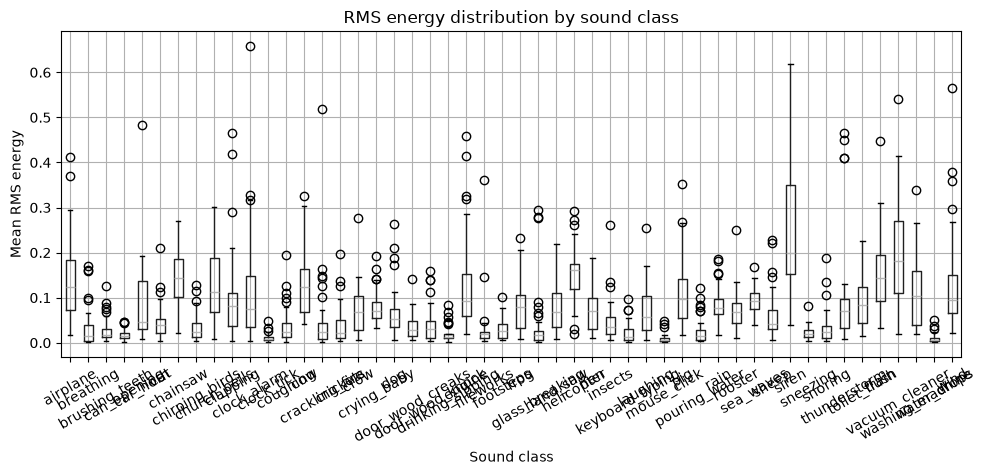

In [24]:
features_df.boxplot(
    column="rms_energy_mean",
    by="category",
    figsize=(10, 5),
    rot=30,
)

plt.suptitle("")
plt.title("RMS energy distribution by sound class")
plt.xlabel("Sound class")
plt.ylabel("Mean RMS energy")
plt.tight_layout()
plt.show()


## Second milestone complete

You have now:

1. Loaded all selected recordings
2. Extracted 31 numerical features per recording
3. Built a 200-row feature table
4. Saved it as `audio_features.csv`

The next notebook will train and evaluate a Random Forest classifier.
